# Features — Filtragem, Conjuntos T/M/F e Z-score

Continuação direta de `1_EDA.ipynb`. A EDA estabeleceu três decisões que entram em vigor aqui:

1. Higiene do CSV (remover `Unnamed: 0`, `Rec` e duplicatas por `UID`).
2. **Segregar goleiros** dos jogadores de linha antes de qualquer cálculo de distância — os atributos `Aer`, `Cmd`, `Han`, `Kic`, `1v1`, `Ref`, `TRO`, `Pun`, `Thr`, `Com` formam um regime bimodal que dominaria qualquer ranking de similaridade entre goleiros e não-goleiros.
3. Trabalhar com **famílias de atributos** (Técnico, Mental, Físico) como conjuntos candidatos de features.

Escopo deste notebook:

- Filtragem de goleiros (`primary_role == 'GK'`).
- Padronização e construção dos conjuntos `T(14)`, `M(14)`, `F(8)`.
- Normalização via **z-score**, ajustada apenas na população de jogadores de linha.
- Persistência dos artefatos em `data/processed/` para o próximo passo (modelagem de similaridade).

---

## 1. Setup

Importação das bibliotecas e configuração de exibição. Mantemos o mesmo estilo do notebook 1.

In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", context="notebook")

## 2. Carregamento e higiene (recap)

Repetimos exatamente o mesmo pipeline de limpeza do notebook 1, em uma única célula. Não é tarefa nova — é a base sobre a qual a filtragem e a padronização se apoiam, e mantê-la explícita aqui evita o acoplamento entre notebooks.

In [2]:
def project_root(marker: str = ".git") -> Path:
    for parent in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Marker {marker!r} not found in any parent of {Path.cwd()}")


ROOT = project_root()
DATA_DIR = ROOT / "data"
OUT_DIR = DATA_DIR / "processed"
OUT_DIR.mkdir(exist_ok=True)

df_raw = pd.read_csv(DATA_DIR / "merged_players.csv")
df = (
    df_raw
    .drop(columns=["Unnamed: 0", "Rec"])
    .drop_duplicates(subset="UID")
    .reset_index(drop=True)
)
print(f"Raw:    {df_raw.shape}")
print(f"Limpo:  {df.shape}")

Raw:    (91672, 88)
Limpo:  (87163, 86)


## 3. Papel primário e filtragem de goleiros

Reaplicamos `primary_role` (definida no notebook 1) para extrair o papel principal de cada jogador a partir de `Position`. A partir dele, dividimos o conjunto em dois subconjuntos disjuntos:

- `df_gk`  — jogadores com papel `GK`.
- `df_outfield` — todos os outros (`DEF`, `WB`, `DM`, `MID`, `AM`, `FW`).

Toda a padronização posterior é feita **na população de jogadores de linha**. Os goleiros são preservados em um DataFrame separado: o estudo de similaridade entre goleiros é um problema legítimo, mas com conjuntos de features próprios (atributos GK) e por isso fica reservado para uma etapa posterior.

In [3]:
ROLE_MAP = {
    "GK": "GK",
    "D": "DEF",
    "WB": "WB",
    "DM": "DM",
    "M": "MID",
    "AM": "AM",
    "ST": "FW",
}


def primary_role(pos_str: str) -> str:
    first_token = pos_str.split(",")[0].strip()
    base = re.split(r"[/ (]", first_token)[0]
    return ROLE_MAP.get(base, "OTHER")


df["primary_role"] = df["Position"].map(primary_role)

df_gk = df[df["primary_role"] == "GK"].reset_index(drop=True)
df_outfield = df[df["primary_role"] != "GK"].reset_index(drop=True)

print(f"Total:        {len(df):>6,}")
print(f"Goleiros:     {len(df_gk):>6,} ({len(df_gk) / len(df):.1%})")
print(f"Linha:        {len(df_outfield):>6,} ({len(df_outfield) / len(df):.1%})")
print("\nDistribuição por papel (sem GK):")
df_outfield["primary_role"].value_counts()

Total:        87,163
Goleiros:      8,880 (10.2%)
Linha:        78,283 (89.8%)

Distribuição por papel (sem GK):


primary_role
DEF    29946
MID    15738
AM     12930
FW      9717
DM      9179
WB       773
Name: count, dtype: int64

Um teste-sanidade rápido: nenhum dos atributos exclusivos de goleiro (`Aer`, `Cmd`, `Han`, `Kic`, `1v1`, `Ref`, `TRO`, `Pun`, `Thr`, `Com`) será usado nos conjuntos `T`, `M`, `F`. Confirmar isso evita um erro silencioso comum: deixar passar um atributo de GK em um conjunto destinado a jogadores de linha desloca a escala e contamina a interpretação.

In [4]:
gk_only = {"Aer", "Cmd", "Com", "Ecc", "Han", "Kic", "1v1", "Ref", "TRO", "Pun", "Thr"}
outfield_means = df_outfield[list(gk_only)].mean().round(2)
gk_means = df_gk[list(gk_only)].mean().round(2)

comparison = pd.DataFrame({"outfield_mean": outfield_means, "gk_mean": gk_means})
comparison["ratio_gk/outfield"] = (comparison["gk_mean"] / comparison["outfield_mean"]).round(2)
comparison.sort_values("ratio_gk/outfield", ascending=False)

,outfield_mean,gk_mean,ratio_gk/outfield
Ref,2.10,12.18,5.80
Han,2.10,11.57,5.51
Aer,2.10,11.05,5.26
Kic,2.10,10.27,4.89
TRO,2.10,9.74,4.64
Cmd,2.11,9.73,4.61
Pun,2.10,9.60,4.57
1v1,2.10,9.54,4.54
Com,2.10,9.20,4.38
Thr,2.10,8.79,4.19


O quadro confirma o motivo da segregação: nos atributos GK, jogadores de linha têm média ≈ 2 (valor típico de atributo *não treinado*) e goleiros média ≈ 12–14. A razão entre médias varia entre **5× e 7×**. Misturar as duas populações em qualquer cálculo baseado em distância infla a variância dessas colunas e domina o ranking de similaridade.

## 4. Conjuntos de features `T(10)`, `M(14)`, `F(8)`, `SP(4)`

Os conjuntos são derivados das famílias técnicas/mentais/físicas da documentação do FM, mapeadas para as colunas do CSV no notebook 1. Eles cobrem **as 36 dimensões usadas pelo estudo de similaridade** entre jogadores de linha.

- **`T(10)` — Técnico (estilo de jogo intrínseco).** Habilidades dependentes de coordenação fina e leitura técnica em jogo aberto: cruzamento, drible, finalização, primeiro toque, cabeceio, passe longo, marcação, técnica.
- **`M(14)` — Mental.** Atributos cognitivos e de comportamento em campo: antecipação, posicionamento, visão, agressividade, trabalho, decisão, liderança, etc.
- **`F(8)` — Físico.** Capacidades motoras puras: aceleração, agilidade, equilíbrio, salto, *natural fitness*, pace, fôlego, força.
- **`SP(4)` — Set Pieces (bola parada).** Cobrança de escanteios (`Cor`), faltas (`Fre`), pênaltis (`Pen`) e arremessos longos (`L Th`).

### Refinamento metodológico: por que separar `SP` de `T`?

Os 4 atributos de bola parada (`Cor`, `Fre`, `Pen`, `L Th`) capturam **papel/responsabilidade atribuída pelo time** — quem cobra escanteios, faltas, pênaltis, arremessos longos — e **não estilo de jogo intrínseco** do jogador. Mantê-los no conjunto Técnico poluiria o sinal de similaridade tática: dois atacantes com perfis técnicos similares podem ficar artificialmente distantes apenas porque um é o batedor oficial do time e o outro não.

Por isso `SP(4)` é tratado como conjunto **separado**, **fora do experimento principal** (3 conjuntos × 3 distâncias = 9 condições). Fica reservado para uma análise complementar específica: *"o método vencedor identifica corretamente especialistas em bola parada?"*.

Notamos que estes conjuntos **excluem deliberadamente**:

- Atributos de GK (decisão da §3 acima).
- Atributos *hidden / personalidade* (`Amb`, `Loy`, `Pres`, ...). Esses não medem desempenho em campo — medem traços de personalidade. O estudo pode reincorporá-los como variáveis de controle, mas o conjunto base de similaridade permanece restrito a habilidades observáveis em jogo.
- Dados de mercado, idade, físico bruto (altura/peso). Candidatos a análise complementar, fora do escopo deste notebook.

In [5]:
FEATURE_SETS = {
    "technical": [
        "Cro", "Dri", "Fin", "Fir", "Hea", "Lon", "Mar", "Pas", "Tck", "Tec",
    ],
    "mental": [
        "Agg", "Ant", "Bra", "Cmp", "Cnt", "Dec", "Det", "Fla",
        "Ldr", "OtB", "Pos", "Tea", "Vis", "Wor",
    ],
    "physical": [
        "Acc", "Agi", "Bal", "Jum", "Nat.1", "Pac", "Sta", "Str",
    ],
    "set_pieces": [
        "Cor", "Fre", "Pen", "L Th",
    ],
}

LABELS = {"technical": "T(10)", "mental": "M(14)", "physical": "F(8)", "set_pieces": "SP(4)"}
attr_to_set = {a: s for s, cols in FEATURE_SETS.items() for a in cols}

for name, cols in FEATURE_SETS.items():
    missing = [c for c in cols if c not in df_outfield.columns]
    overlap_gk = [c for c in cols if c in gk_only]
    print(f"{LABELS[name]:7s}  faltando: {missing or 'nenhuma'}  | overlap GK: {overlap_gk or 'nenhum'}")

ALL_FEATURES = [c for cols in FEATURE_SETS.values() for c in cols]
assert len(set(ALL_FEATURES)) == len(ALL_FEATURES), "Há atributos repetidos entre conjuntos"
print(f"\nTotal de features ({' + '.join(LABELS[k] for k in FEATURE_SETS)}): {len(ALL_FEATURES)}")

T(10)    faltando: nenhuma  | overlap GK: nenhum
M(14)    faltando: nenhuma  | overlap GK: nenhum
F(8)     faltando: nenhuma  | overlap GK: nenhum
SP(4)    faltando: nenhuma  | overlap GK: nenhum

Total de features (T(10) + M(14) + F(8) + SP(4)): 36


## 5. Diagnóstico pré-padronização

Antes de aplicar z-score, vale **confirmar empiricamente** o argumento para padronizar. Os 36 atributos vivem todos na escala 1–20, então não há diferença de unidade — mas as médias e desvios variam significativamente entre eles:

- Atributos "densos" para jogadores de linha (ex.: `Pac`, `Sta`, `Tea`, `Wor`) têm média próxima de 10–11 e desvio em torno de 2.
- Atributos "esparsos" (ex.: `L Th`, `Pen`, `Fre`, `Cor`) têm médias em 5–7 e desvios maiores, com cauda longa.

Sem padronização, atributos com maior desvio absoluto dominam a distância euclidiana — não porque sejam mais informativos, mas simplesmente por ocuparem mais espaço numérico. O z-score remove esse viés.

In [6]:
stats_pre = df_outfield[ALL_FEATURES].agg(["mean", "std", "min", "max"]).T
stats_pre["set"] = [attr_to_set[a] for a in ALL_FEATURES]
stats_pre = stats_pre[["set", "mean", "std", "min", "max"]].round(2)
stats_pre

,set,mean,std,min,max
Cro,technical,8.13,3.30,1.0,20.0
Dri,technical,8.89,3.51,1.0,20.0
Fin,technical,8.13,3.45,1.0,19.0
Fir,technical,10.59,2.46,1.0,20.0
Hea,technical,8.85,3.18,1.0,20.0
Lon,technical,7.69,2.96,1.0,19.0
Mar,technical,8.17,3.20,1.0,18.0
Pas,technical,9.90,2.63,1.0,20.0
Tck,technical,8.83,3.71,1.0,19.0
Tec,technical,10.32,2.80,1.0,20.0


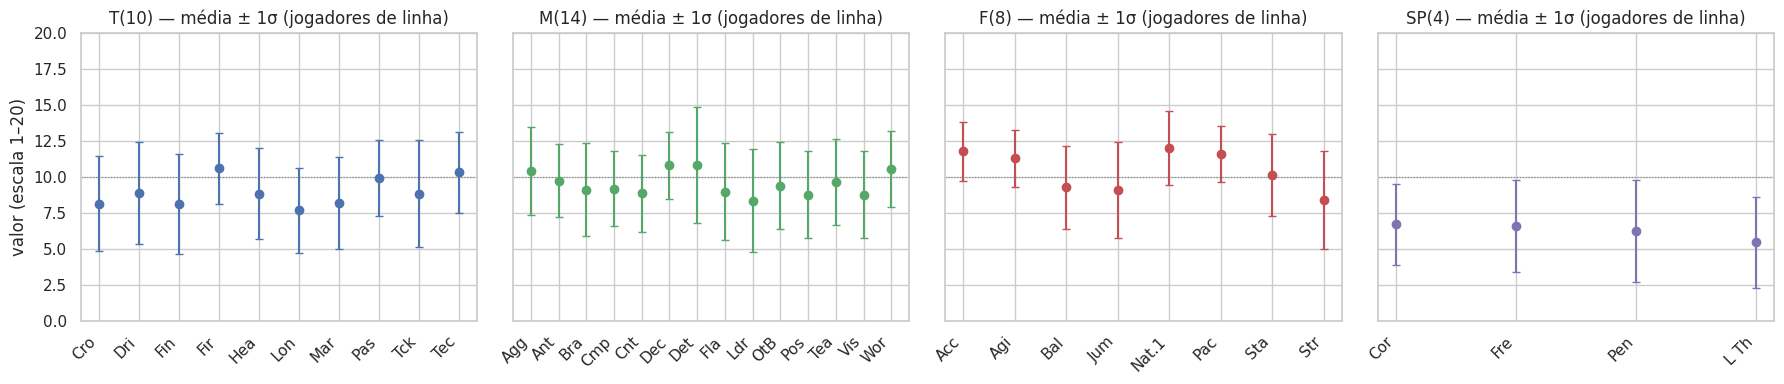

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
palette = {"technical": "#4C72B0", "mental": "#55A868", "physical": "#C44E52", "set_pieces": "#8172B2"}
for ax, (name, cols) in zip(axes, FEATURE_SETS.items()):
    sub = stats_pre.loc[cols]
    ax.errorbar(
        x=range(len(cols)),
        y=sub["mean"],
        yerr=sub["std"],
        fmt="o",
        color=palette[name],
        capsize=3,
    )
    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels(cols, rotation=45, ha="right")
    ax.set_title(f"{LABELS[name]} — média ± 1σ (jogadores de linha)")
    ax.set_ylim(0, 20)
    ax.axhline(10, color="gray", linestyle=":", linewidth=0.8)
axes[0].set_ylabel("valor (escala 1–20)")
fig.tight_layout()
plt.show()

O gráfico torna o ponto visualmente óbvio. Em `T`, atributos como `L Th` (≈5) e `Tec` (≈10) têm médias muito diferentes; em `M`, `Tea`/`Wor` ficam acima de 10 enquanto `Ldr`/`Fla` ficam mais baixos; em `F`, `Bal`/`Pac`/`Sta` ficam concentrados em ~11 mas `Str` está em ~8.

A linha pontilhada em 10 ajuda a ver que **nenhum atributo vive realmente "centrado"** — qualquer escolha de origem (média global, mediana teórica) deslocaria a métrica de forma assimétrica. O z-score remove essa escolha arbitrária ao centrar cada atributo na própria média e escalar pelo próprio desvio.

## 6. Normalização: z-score por atributo

Aplicamos $z_{ij} = (x_{ij} - \mu_j) / \sigma_j$, onde $\mu_j$ e $\sigma_j$ são estimados na **população de jogadores de linha** (não no conjunto total). Esta é uma decisão deliberada:

- Estimar $\mu, \sigma$ no conjunto total faria o ponto-zero refletir uma mistura artificial linha+GK, e cada atributo GK-irrelevante (a maioria dos 36) teria sua escala levemente distorcida pelos goleiros.
- Como o estudo de similaridade aqui é entre jogadores de linha, a distribuição de referência **é** a deles.

Sobre a escolha do z-score frente a alternativas:

- **Min-max ([0, 1])** preserva o intervalo, mas é dominado por outliers e desperdiça resolução nas caudas que importam (jogadores de elite com 18+ em algum atributo).
- **Robust scaler (mediana/IQR)** é resistente a outliers, mas neste dataset os "outliers" *são justamente os jogadores de interesse* (extremos por mérito, não por erro).
- **Sem normalização** privilegia atributos com maior desvio absoluto na distância euclidiana, como discutido na §5.

Z-score é a escolha mais conservadora: assume normalidade aproximada (compatível com o que a EDA mostrou), preserva a forma da distribuição e dá peso uniforme a todas as dimensões.

Persistimos $\mu$ e $\sigma$ usados para que a transformação seja **reproduzível** em qualquer subconjunto futuro (uma liga específica, um time, ou os goleiros, caso se decida aplicar a mesma transformação a eles).

In [8]:
mu = df_outfield[ALL_FEATURES].mean()
sigma = df_outfield[ALL_FEATURES].std(ddof=0)

z = (df_outfield[ALL_FEATURES] - mu) / sigma
z.insert(0, "primary_role", df_outfield["primary_role"].values)
z.insert(0, "UID", df_outfield["UID"].values)

print(f"Matriz z-score: {z.shape}")
z.head()

Matriz z-score: (78283, 38)


,UID,primary_role,Cro,Dri,Fin,Fir,Hea,Lon,Mar,Pas,Tck,Tec,Agg,Ant,Bra,Cmp,Cnt,Dec,Det,Fla,Ldr,OtB,Pos,Tea,Vis,Wor,Acc,Agi,Bal,Jum,Nat.1,Pac,Sta,Str,Cor,Fre,Pen,L Th
0,2002078863,AM,-0.646928,1.740213,0.251808,-1.053542,-0.894980,-0.571400,-1.613272,-0.721555,-1.032062,0.958748,-0.794893,-0.693684,-0.346722,-1.220765,-1.068719,-0.771912,0.293227,0.900368,1.023774,0.202063,-1.592046,0.456843,-1.256306,0.168641,0.107037,0.862771,0.939574,-1.538883,-0.003455,-0.826399,-1.109668,-1.004522,-1.321849,-0.186256,-0.915472,-0.461730
1,2002078833,MID,-0.646928,-0.821426,-0.908712,0.983126,-0.894980,-0.233676,0.572188,1.941079,-0.762455,1.673474,-0.141448,-0.693684,-0.967532,1.088910,-0.320145,-0.771912,0.043029,0.009134,0.742406,-0.132889,0.075010,2.474979,0.409131,0.921433,-1.363683,0.361853,0.245524,-2.440951,-1.573883,-0.826399,-0.406692,-1.298448,-0.610183,0.444341,-0.068594,-0.461730
2,2002078813,DEF,-0.950415,-1.390679,-1.198842,-1.053542,0.361203,-0.233676,-0.052230,-0.721555,0.046367,-0.113340,-1.448338,0.096883,2.136518,-0.450873,-0.320145,-0.771912,0.293227,-1.773332,1.305141,-1.137746,0.075010,0.456843,-0.590131,-1.336943,-0.873443,0.862771,0.245524,0.265252,-1.181276,0.731542,-0.406692,-0.416670,-0.254351,-1.132152,-0.350887,0.496845
3,2002078799,DEF,-0.039954,-1.390679,-1.779102,-1.868210,-1.209026,-1.584573,-0.676647,-1.101932,-0.492848,-0.113340,1.165442,-1.484251,2.446923,-1.605710,-0.694432,-0.342321,-2.458958,-2.070410,-1.789898,-2.142604,-1.258635,0.793199,-1.256306,1.297829,0.107037,-1.140901,-1.142577,-0.035438,-1.966490,-1.865026,-0.406692,-1.004522,-0.966016,-1.132152,-0.915472,0.177320
4,2002078794,AM,-0.343441,0.032454,0.541938,1.797793,-0.580934,0.104049,-1.301064,0.799950,-0.492848,1.673474,-0.468170,-0.298400,0.274088,-0.065927,-1.068719,-1.201503,0.793625,1.494523,-0.383062,0.202063,-0.591812,-0.888581,-0.257044,-0.584151,-1.363683,0.862771,-0.795552,0.866630,1.566972,-0.826399,-1.109668,-1.004522,1.524813,1.074939,-0.350887,-0.142205


## 7. Validação pós-padronização

Após z-score, cada coluna em `z[ALL_FEATURES]` deve ter média ≈ 0 e desvio ≈ 1. Verificamos numericamente — qualquer desvio significativo aqui indicaria bug no pipeline.

In [9]:
stats_pos = z[ALL_FEATURES].agg(["mean", "std", "min", "max"]).T.round(3)
stats_pos["set"] = [attr_to_set[a] for a in ALL_FEATURES]
stats_pos = stats_pos[["set", "mean", "std", "min", "max"]]

print("Resumo agregado por conjunto:")
print(stats_pos.groupby("set")[["mean", "std"]].agg(["mean", "min", "max"]).round(3))
stats_pos.head(10)

Resumo agregado por conjunto:
           mean            std          
           mean  min  max mean  min  max
set                                     
mental      0.0  0.0  0.0  1.0  1.0  1.0
physical    0.0 -0.0 -0.0  1.0  1.0  1.0
set_pieces  0.0 -0.0 -0.0  1.0  1.0  1.0
technical   0.0 -0.0 -0.0  1.0  1.0  1.0


,set,mean,std,min,max
Cro,technical,-0.0,1.0,-2.164,3.602
Dri,technical,-0.0,1.0,-2.245,3.163
Fin,technical,0.0,1.0,-2.069,3.153
Fir,technical,0.0,1.0,-3.905,3.834
Hea,technical,0.0,1.0,-2.465,3.502
Lon,technical,0.0,1.0,-2.260,3.819
Mar,technical,0.0,1.0,-2.238,3.070
Pas,technical,0.0,1.0,-3.384,3.843
Tck,technical,-0.0,1.0,-2.110,2.742
Tec,technical,0.0,1.0,-3.330,3.460


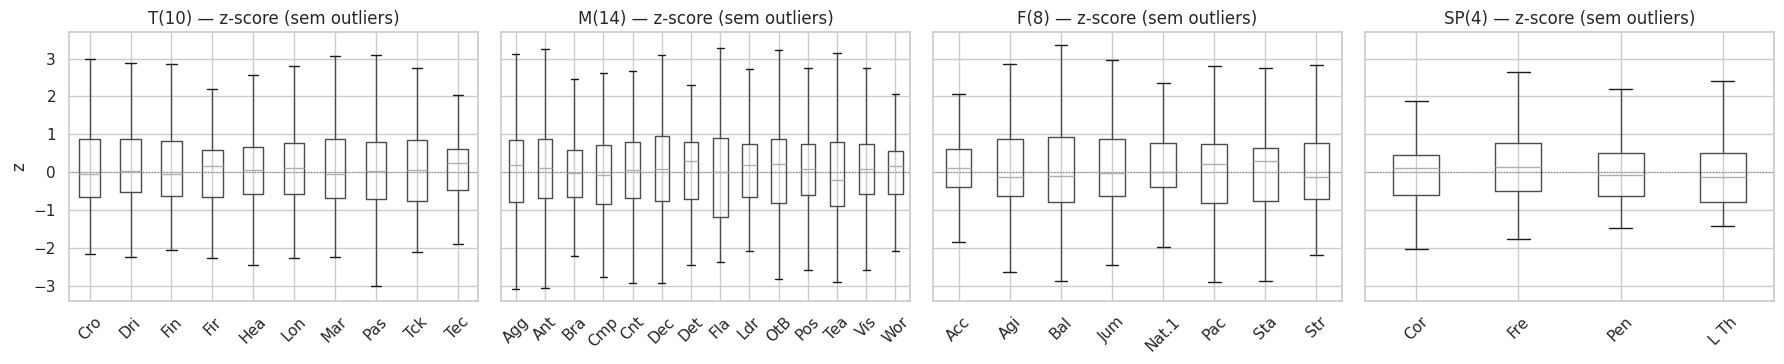

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.8), sharey=True)
for ax, (name, cols) in zip(axes, FEATURE_SETS.items()):
    z[cols].boxplot(ax=ax, rot=45, showfliers=False)
    ax.set_title(f"{LABELS[name]} — z-score (sem outliers)")
    ax.axhline(0, color="gray", linestyle=":", linewidth=0.8)
axes[0].set_ylabel("z")
fig.tight_layout()
plt.show()

Todas as caixas se alinham em torno do zero, com IQR comparável entre atributos. Esta é a propriedade que o z-score garante e que torna a distância euclidiana (ou qualquer métrica baseada em diferença) **comparável dimensão a dimensão** — uma diferença de 1.0 em `Pas` significa o mesmo "1 desvio" que em `Bal` ou em `Cor`.

## 8. Persistência dos artefatos

Salvamos em `data/processed/`:

- `outfield_z.csv` — matriz z-score com `UID`, `primary_role` e as 36 colunas padronizadas (entrada do próximo notebook).
- `outfield_raw.csv` — os mesmos jogadores na escala 1–20, para qualquer reanálise sem padronização.
- `gk_raw.csv` — goleiros preservados (para estudo separado).
- `feature_sets.json` — definição dos conjuntos `T`, `M`, `F`.
- `zscore_stats.csv` — `μ` e `σ` usados, para reaplicar a transformação a qualquer subconjunto futuro.

Estes arquivos ficam fora do versionamento (`.gitignore` cobre `data/**/*.csv` e `data/**/*.json`) — são derivados reproduzíveis a partir do CSV bruto + este notebook.

In [11]:
z.to_csv(OUT_DIR / "outfield_z.csv", index=False)
df_outfield[["UID", "primary_role", *ALL_FEATURES]].to_csv(OUT_DIR / "outfield_raw.csv", index=False)
df_gk[["UID", "primary_role", *ALL_FEATURES]].to_csv(OUT_DIR / "gk_raw.csv", index=False)

with open(OUT_DIR / "feature_sets.json", "w") as f:
    json.dump(FEATURE_SETS, f, indent=2)

pd.DataFrame({"mu": mu, "sigma": sigma}).to_csv(OUT_DIR / "zscore_stats.csv")

for p in sorted(OUT_DIR.glob("*")):
    print(f"{p.name:25s} {p.stat().st_size / 1024:>8.1f} KB")

feature_sets.json              0.5 KB
gk_raw.csv                   828.2 KB
outfield_raw.csv            7885.8 KB
outfield_z.csv             55031.1 KB
zscore_stats.csv               1.4 KB


## 9. Síntese

**Estado após este notebook:**

- Goleiros segregados (`gk_raw.csv`) — fora da modelagem base de similaridade entre jogadores de linha.
- 36 features definidas em **quatro conjuntos disjuntos**: `T(10)` Técnico, `M(14)` Mental, `F(8)` Físico, `SP(4)` Set Pieces.
- Matriz z-score (`outfield_z.csv`) com `μ` e `σ` calculados **na população de jogadores de linha** e persistidos para reuso.
- Cada coluna em z-score tem média ≈ 0 e desvio ≈ 1 (verificado na §7).

**Decisões metodológicas tomadas aqui:**

1. **Estimar $\mu, \sigma$ apenas em jogadores de linha** — evita contaminação da escala pelos goleiros.
2. **Excluir atributos hidden/personalidade dos conjuntos base** — podem voltar como variáveis de controle, mas não fazem parte do espaço de similaridade.
3. **Separar `SP(4)` de `T`** — bola parada captura papel/responsabilidade no time, não estilo de jogo intrínseco. Mantido como conjunto à parte, **fora do experimento principal** (3 conjuntos × 3 distâncias = 9 condições); reservado para análise complementar sobre identificação de especialistas em bola parada.
4. **Z-score em vez de min-max ou robust** — preserva forma da distribuição e dá peso uniforme; os "outliers" do FM são justamente o sinal de interesse.

**Próximos passos (notebook 3 — modelagem):**

- Implementar as três métricas de distância (Euclidiana, Cosseno, Pearson) sobre os conjuntos `T`, `M`, `F` (e combinações). `SP` fica reservado para a análise complementar.
- Construir o experimento controlado de similaridade conhecida por construção (sub-pergunta 2 do README).
- Avaliar agrupamento por função tática usando `primary_role` como rótulo (sub-pergunta 1).